### Machine Learning Foundations Assignment

This notebook covers core Machine Learning concepts using 3 datasets.
* A user-defined Dataset [Student Performance]
* Kaggle Dataset [Titanic]
* Built-in Scikit-Learn Dataset [Iris]

I aimed to cover the following topics in a logical order:
1. Descriptive Statistics
2. Probability
3. Probability Distributions
4. Data Preprocessing
5. Sampling & CLT
6. Hypothesis Testing
7. Correlation & Covariance
8. Linear Algebra
9. Calculus Basics
10. Regression
11. Classification
12. Clustering
13. PCA
14. Model Evaluation
15. Hyperparameter Tuning

In [92]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# colour scheme
primary = "#5E1B53"
secondary = "#CB84D6"
accent = "#9C0DA1"
neutral = "#616161"

# set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [93]:
# Load raw datasets

# 1. Student dataset
data = {
    "student_id": range(1, 11),
    "hours_studied": [4.5, 7.0, 2.1, 9.5, 6.2, 1.5, 8.0, 5.5, 3.8, 8.5],
    "attendance": [85, 92, 70, 98, 88, 65, 95, 80, 75, 90],
    "assignments_completed": [8, 9, 5, 10, 8, 3, 9, 7, 6, 10],
    "sleep_hours": [7, 8, 6, 7, 5, 6, 8, 7, 6, 8],
    "test_score": [72, 88, 55, 96, 78, 48, 92, 75, 64, 94],
    "result": [1, 1, 0, 1, 1, 0, 1, 1, 0, 1]
}
dfstud = pd.DataFrame(data)

# 2. Titanic dataset
dftit_raw = pd.read_csv("titanic.csv")

# 3. Iris dataset
iris = load_iris()
dfiris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
dfiris["species_id"] = iris.target
dfiris["species_name"] = iris.target_names[iris.target]

### Topic 1 - Descriptive Statistics

Descriptive statistics summarise the main features of a dataset. Common measures include mean, median, standard deviation, and quartiles. These give a quick sense of the central tendency and spread of each variable.

**1. User-defined Dataset**

In [94]:
dfstud.describe(include="all")

,student_id,hours_studied,attendance,assignments_completed,sleep_hours,test_score,result
count,10.00000,10.00000,10.000000,10.00000,10.000000,10.000000,10.000000
mean,5.50000,5.66000,83.800000,7.50000,6.800000,76.200000,0.700000
std,3.02765,2.69122,10.992927,2.27303,1.032796,16.711939,0.483046
min,1.00000,1.50000,65.000000,3.00000,5.000000,48.000000,0.000000
25%,3.25000,3.97500,76.250000,6.25000,6.000000,66.000000,0.250000
50%,5.50000,5.85000,86.500000,8.00000,7.000000,76.500000,1.000000
75%,7.75000,7.75000,91.500000,9.00000,7.750000,91.000000,1.000000
max,10.00000,9.50000,98.000000,10.00000,8.000000,96.000000,1.000000


**2. Kaggle Dataset**

In [95]:
dftit_raw.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


**3. Iris Dataset**

In [96]:
dfiris.describe(include="all")

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species_name
count,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,1.000000,NaN
std,0.828066,0.435866,1.765298,0.762238,0.819232,NaN
min,4.300000,2.000000,1.000000,0.100000,0.000000,NaN
25%,5.100000,2.800000,1.600000,0.300000,0.000000,NaN
50%,5.800000,3.000000,4.350000,1.300000,1.000000,NaN
75%,6.400000,3.300000,5.100000,1.800000,2.000000,NaN


### Topic 2 - Probability

Probability measures the likelihood of an event. We can compute basic probabilities, conditional probabilities, and apply Bayes' theorem to update beliefs based on new information.

**1. User-defined Dataset**

P(Pass) = 70.00%
P(Pass | Hours Studied > 6) = 100.00%
Bayes' Theorem: P(High Study | Pass) = 71.43%


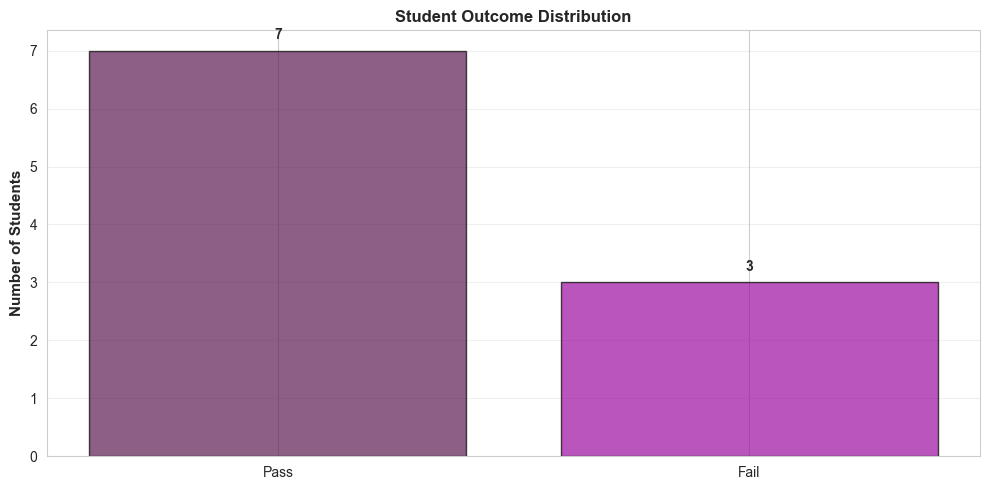

In [97]:
total_students = len(dfstud)
pass_students = (dfstud['result'] == 1).sum()
p_pass = pass_students / total_students
print(f"P(Pass) = {p_pass:.2%}")

high_study = (dfstud['hours_studied'] > 6).sum()
high_study_pass = ((dfstud['hours_studied'] > 6) & (dfstud['result'] == 1)).sum()
p_pass_given_high_study = high_study_pass / high_study if high_study > 0 else 0
print(f"P(Pass | Hours Studied > 6) = {p_pass_given_high_study:.2%}")

p_high_study = high_study / total_students
p_pass_given_high_study_calc = (p_pass_given_high_study * p_high_study) / p_pass
print(f"Bayes' Theorem: P(High Study | Pass) = {p_pass_given_high_study_calc:.2%}")

fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Pass', 'Fail']
values = [pass_students, total_students - pass_students]
colors = [primary, accent]
ax.bar(categories, values, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Number of Students', fontsize=11, fontweight='bold')
ax.set_title('Student Outcome Distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values):
    ax.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**2. Kaggle Dataset**

P(Survived) = 38.38%
P(Female) = 35.24%
P(Survived AND Female) = 26.15%

Conditional Probabilities:
P(Survived | Female) = 74.20%
P(Survived | Male) = 18.89%


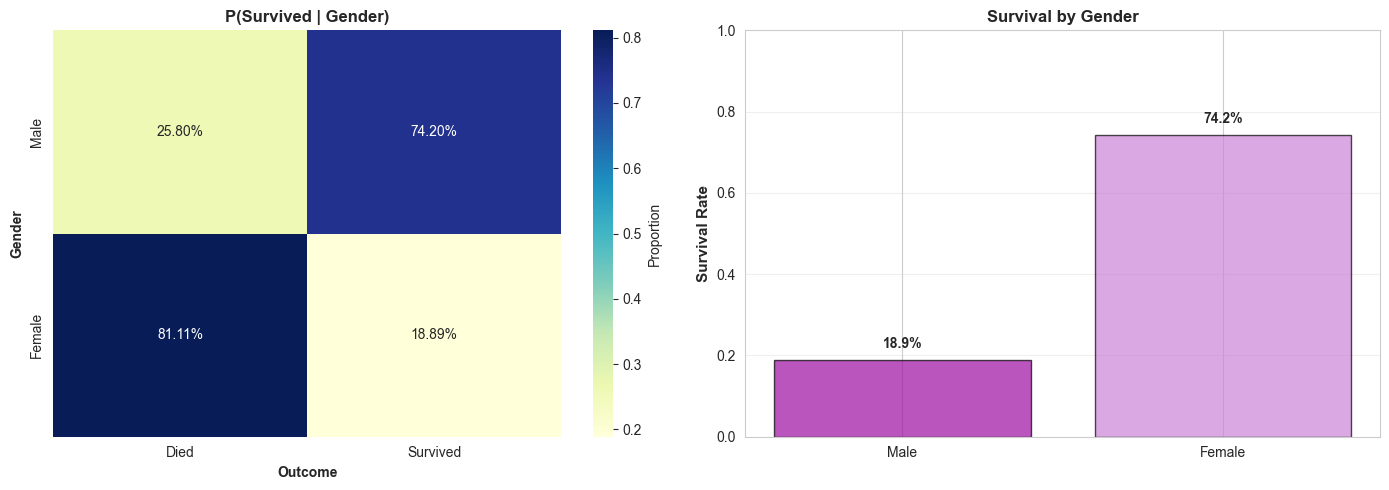

In [ ]:
p_survived = dftit_raw['Survived'].mean()
p_female = (dftit_raw['Sex'] == 'female').mean()
p_survived_female = ((dftit_raw['Sex'] == 'female') & (dftit_raw['Survived'] == 1)).mean()

print(f"P(Survived) = {p_survived:.2%}")
print(f"P(Female) = {p_female:.2%}")
print(f"P(Survived AND Female) = {p_survived_female:.2%}")

p_survived_given_female = dftit_raw[dftit_raw['Sex'] == 'female']['Survived'].mean()
p_survived_given_male = dftit_raw[dftit_raw['Sex'] == 'male']['Survived'].mean()
print(f"\nConditional Probabilities:")
print(f"P(Survived | Female) = {p_survived_given_female:.2%}")
print(f"P(Survived | Male) = {p_survived_given_male:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
contingency = pd.crosstab(dftit_raw['Sex'], dftit_raw['Survived'], normalize='index')
sns.heatmap(contingency, annot=True, fmt='.2%', cmap='YlGnBu', xticklabels=['Died', 'Survived'], yticklabels=['Male', 'Female'], ax=axes[0], cbar_kws={'label': 'Proportion'})
axes[0].set_title('P(Survived | Gender)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Outcome', fontweight='bold')
axes[0].set_ylabel('Gender', fontweight='bold')

genders = ['Male', 'Female']
survival_rates = [p_survived_given_male, p_survived_given_female]
axes[1].bar(genders, survival_rates, color=[accent, secondary], edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Survival Rate', fontsize=11, fontweight='bold')
axes[1].set_title('Survival by Gender', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(survival_rates):
    axes[1].text(i, v + 0.03, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**3. Iris Dataset**

In [99]:
p_setosa = (dfiris['species_id'] == 0).mean()
p_versicolor = (dfiris['species_id'] == 1).mean()
p_virginica = (dfiris['species_id'] == 2).mean()
print(f"P(Setosa) = {p_setosa:.2%}")
print(f"P(Versicolor) = {p_versicolor:.2%}")
print(f"P(Virginica) = {p_virginica:.2%}")

high_petal = dfiris['petal length (cm)'].median()
for species_id, species_name in enumerate(iris.target_names):
    species_data = dfiris[dfiris['species_id'] == species_id]['petal length (cm)']
    p_high_given_species = (species_data > high_petal).mean()
    print(f"P(High Petal Length | {species_name}) = {p_high_given_species:.2%}")

P(Setosa) = 33.33%
P(Versicolor) = 33.33%
P(Virginica) = 33.33%
P(High Petal Length | setosa) = 0.00%
P(High Petal Length | versicolor) = 50.00%
P(High Petal Length | virginica) = 100.00%


### Topic 3 - Probability Distributions

A probability distribution describes how values are spread. We can visualise the distribution of a variable and check if it follows a normal [Gaussian] shape by plotting a histogram with a fitted normal curve.

**1. User-defined Dataset**

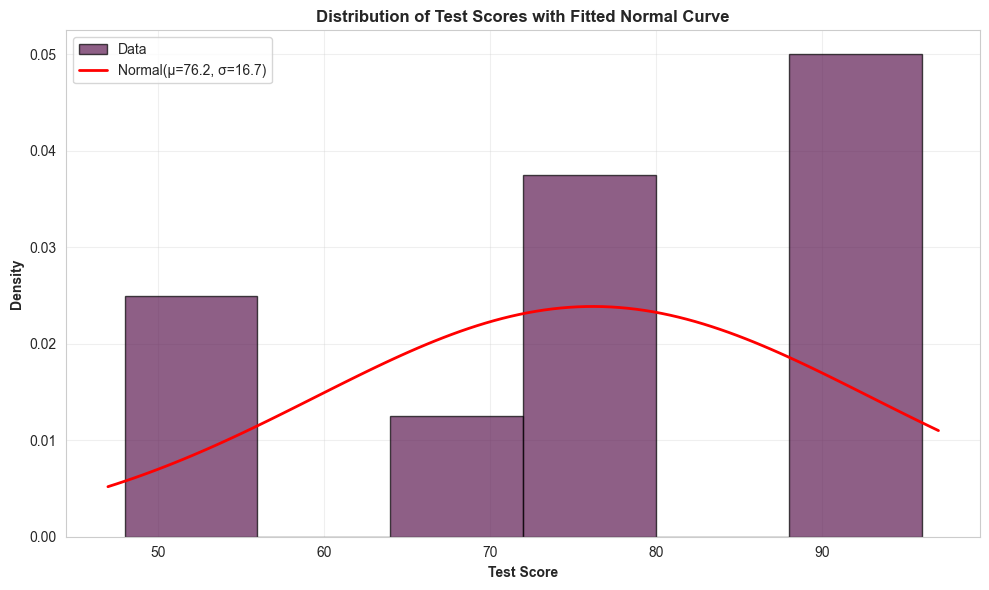

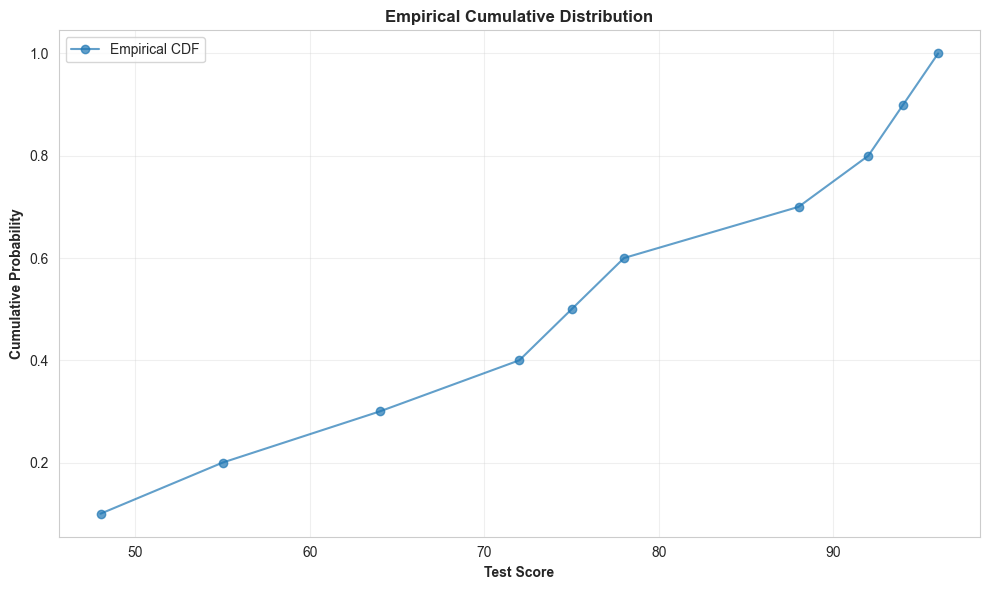

In [100]:
test_scores = dfstud['test_score']
mu, sigma = test_scores.mean(), test_scores.std()
x = np.linspace(test_scores.min() - 1, test_scores.max() + 1, 100)
y = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(test_scores, bins=6, density=True, alpha=0.7, color=primary, edgecolor='black', label='Data')
ax.plot(x, y, 'r-', linewidth=2, label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
ax.set_xlabel('Test Score', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Distribution of Test Scores with Fitted Normal Curve', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# also show empirical cumulative distribution
sorted_scores = np.sort(test_scores)
cdf = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sorted_scores, cdf, 'o-', label='Empirical CDF', alpha=0.7, markersize=6)
ax.set_xlabel('Test Score', fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontweight='bold')
ax.set_title('Empirical Cumulative Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2. Kaggle Dataset**

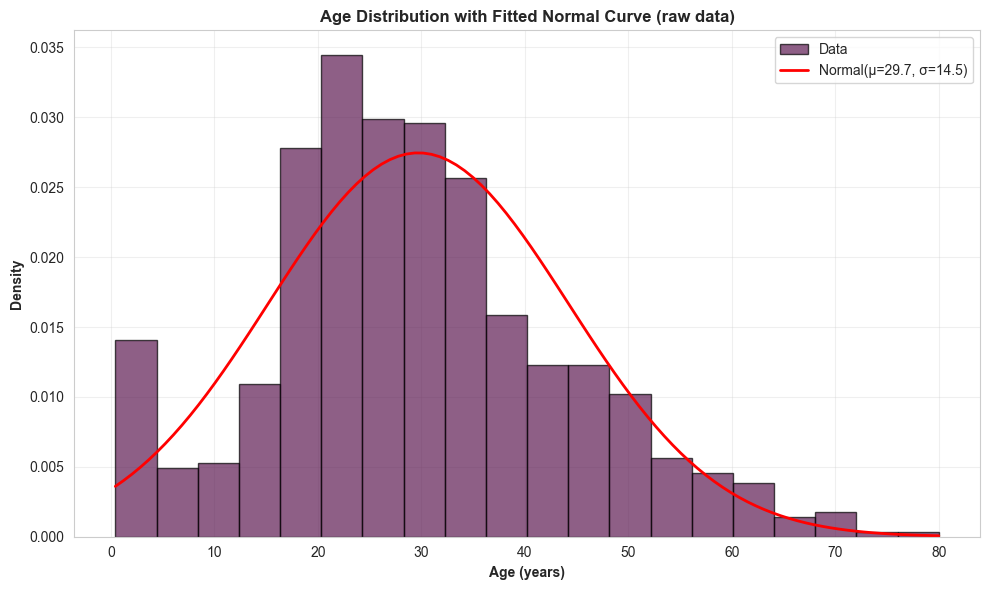

In [ ]:
age_data = dftit_raw['Age'].dropna()
mu, sigma = age_data.mean(), age_data.std()
x = np.linspace(age_data.min(), age_data.max(), 100)
y = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(age_data, bins=20, density=True, alpha=0.7, color=primary, edgecolor='black', label='Data')
ax.plot(x, y, 'r-', linewidth=2, label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
ax.set_xlabel('Age (years)', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Age Distribution with Fitted Normal Curve (raw data)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**3. Iris Dataset**

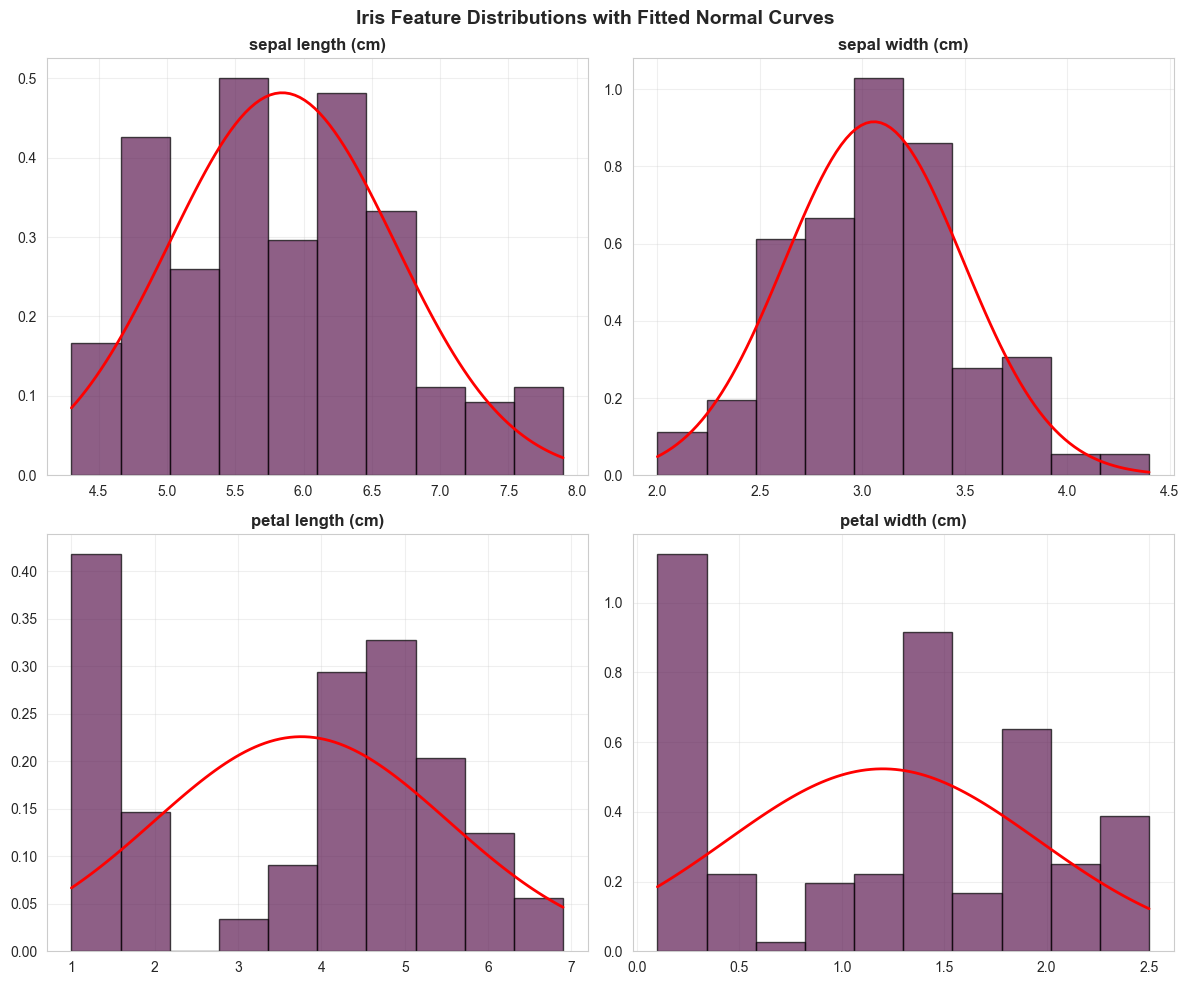

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, feature in enumerate(iris.feature_names):
    data = dfiris[feature]
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    y = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)
    axes[idx].hist(data, bins=10, density=True, alpha=0.7, color=primary, edgecolor='black')
    axes[idx].plot(x, y, 'r-', linewidth=2)
    axes[idx].set_title(f'{feature}', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('Iris Feature Distributions with Fitted Normal Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Topic 4 - Data Preprocessing

Real data often contains missing values, categorical variables, and different scales. Preprocessing steps like imputation, encoding, and scaling are essential before modelling. Here we clean the Titanic dataset, which will be used in all subsequent topics.

**1. User-defined Dataset**

In [103]:
# scale features
features = ['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours']
scaler = StandardScaler()
dfstud_scaled = dfstud.copy()
dfstud_scaled[features] = scaler.fit_transform(dfstud[features])
print("After scaling, mean and std of each feature:")
print(dfstud_scaled[features].mean())
print(dfstud_scaled[features].std())

After scaling, mean and std of each feature:
hours_studied            2.664535e-16
attendance               2.442491e-16
assignments_completed    2.220446e-17
sleep_hours              1.998401e-16
dtype: float64
hours_studied            1.054093
attendance               1.054093
assignments_completed    1.054093
sleep_hours              1.054093
dtype: float64


**2. Kaggle Dataset**

In [ ]:
dftit = dftit_raw.copy()

# impute Age with median
dftit['Age'] = dftit['Age'].fillna(dftit['Age'].median())

# drop Cabin [too many missing]
dftit = dftit.drop(columns=['Cabin'])

# drop rows with missing Embarked [only few]
dftit = dftit.dropna(subset=['Embarked'])

# encode Sex
dftit['Sex'] = dftit['Sex'].map({'male': 0, 'female': 1})

# one-hot encode Embarked
dftit = pd.get_dummies(dftit, columns=['Embarked'], drop_first=True)

print("After preprocessing, columns:")
print(dftit.columns.tolist())
print("\nMissing values after preprocessing:")
print(dftit.isnull().sum())

After preprocessing, columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S']

Missing values after preprocessing:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked_Q     0
Embarked_S     0
dtype: int64


**3. Iris Dataset**

In [105]:
# standardize features for clustering
scaler = StandardScaler()
x_iris_scaled = scaler.fit_transform(dfiris[iris.feature_names])
print("Before scaling - means:")
print(dfiris[iris.feature_names].mean())
print("\nAfter scaling - means:")
print(x_iris_scaled.mean(axis=0))
print("After scaling - stds:")
print(x_iris_scaled.std(axis=0))

Before scaling - means:
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

After scaling - means:
[-4.73695157e-16 -7.81597009e-16 -4.26325641e-16 -4.73695157e-16]
After scaling - stds:
[1. 1. 1. 1.]


### Topic 5 - Sampling & Central Limit Theorem [CLT]

The Central Limit Theorem states that the distribution of sample means approaches a normal distribution as sample size increases, regardless of the population distribution. Bootstrap resampling allows us to estimate the sampling distribution and compute confidence intervals.

**1. User-defined Dataset**

Original mean: 76.20
95% CI for mean: [66.59, 85.70]


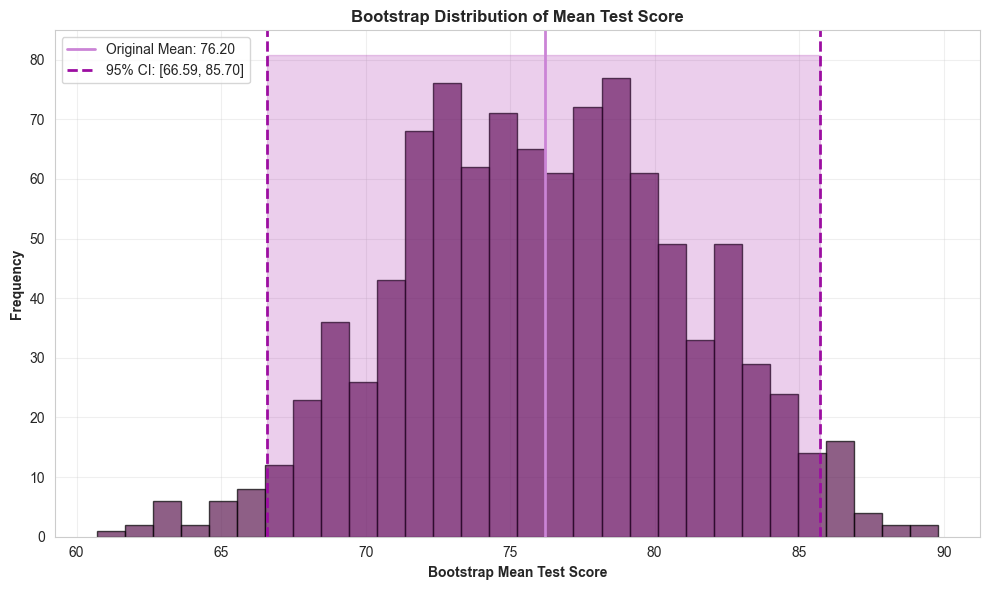

In [106]:
original_mean = dfstud['test_score'].mean()
n_iter = 1000
bootstrap_means = []
np.random.seed(42)
for _ in range(n_iter):
    sample = np.random.choice(dfstud['test_score'], size=len(dfstud), replace=True)
    bootstrap_means.append(sample.mean())
bootstrap_means = np.array(bootstrap_means)
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print(f"Original mean: {original_mean:.2f}")
print(f"95% CI for mean: [{ci_lower:.2f}, {ci_upper:.2f}]")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(bootstrap_means, bins=30, color=primary, edgecolor='black', alpha=0.7)
ax.axvline(original_mean, color=secondary, linestyle='-', linewidth=2, label=f'Original Mean: {original_mean:.2f}')
ax.axvline(ci_lower, color=accent, linestyle='--', linewidth=2, label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
ax.axvline(ci_upper, color=accent, linestyle='--', linewidth=2)
ax.fill_between([ci_lower, ci_upper], 0, ax.get_ylim()[1], alpha=0.2, color=accent)
ax.set_xlabel('Bootstrap Mean Test Score', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Bootstrap Distribution of Mean Test Score', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2. Kaggle Dataset**

Original survival rate: 38.25%
95% CI for survival rate: [34.87%, 41.51%]


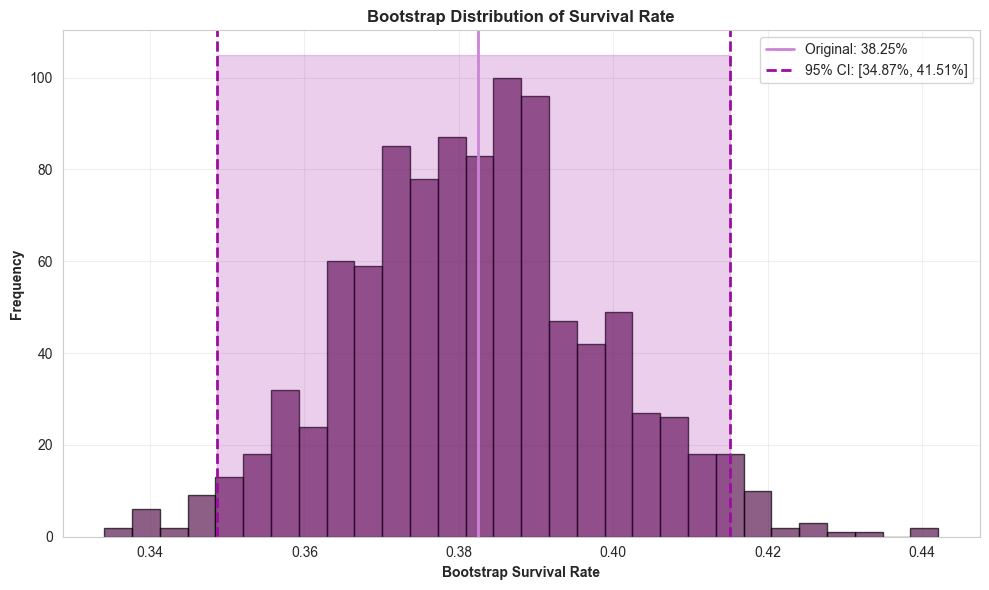

In [107]:
# use cleaned dftit
bootstrap_survival = []
np.random.seed(42)
for _ in range(1000):
    sample = np.random.choice(dftit['Survived'], size=len(dftit), replace=True)
    bootstrap_survival.append(sample.mean())
bootstrap_survival = np.array(bootstrap_survival)
ci_lower = np.percentile(bootstrap_survival, 2.5)
ci_upper = np.percentile(bootstrap_survival, 97.5)

print(f"Original survival rate: {dftit['Survived'].mean():.2%}")
print(f"95% CI for survival rate: [{ci_lower:.2%}, {ci_upper:.2%}]")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(bootstrap_survival, bins=30, color=primary, edgecolor='black', alpha=0.7)
ax.axvline(dftit['Survived'].mean(), color=secondary, linestyle='-', linewidth=2, label=f'Original: {dftit["Survived"].mean():.2%}')
ax.axvline(ci_lower, color=accent, linestyle='--', linewidth=2, label=f'95% CI: [{ci_lower:.2%}, {ci_upper:.2%}]')
ax.axvline(ci_upper, color=accent, linestyle='--', linewidth=2)
ax.fill_between([ci_lower, ci_upper], 0, ax.get_ylim()[1], alpha=0.2, color=accent)
ax.set_xlabel('Bootstrap Survival Rate', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Bootstrap Distribution of Survival Rate', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**3. Iris Dataset**

Original mean sepal length: 5.84
95% CI for mean: [5.71, 5.97]


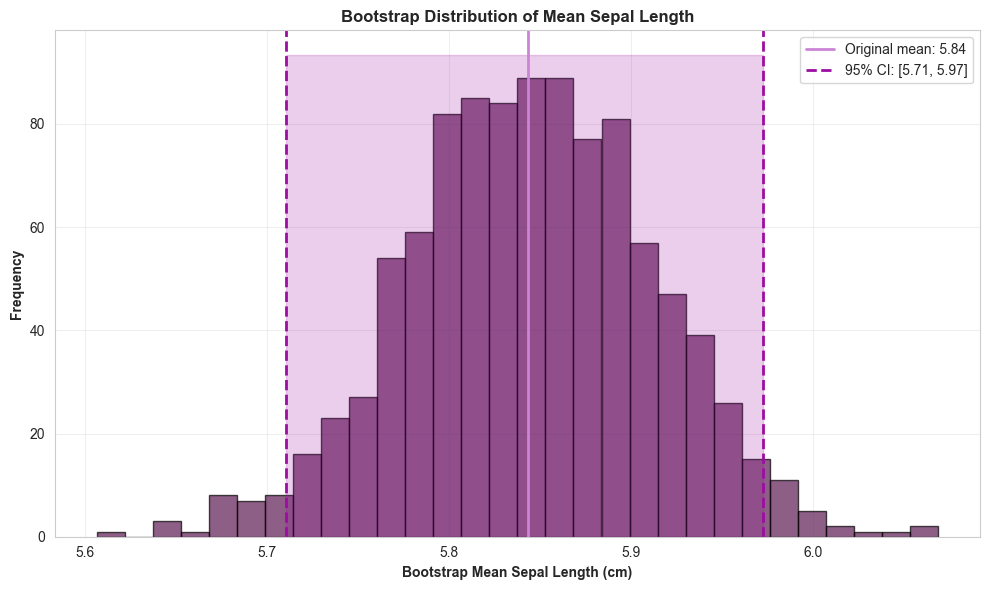

In [108]:
sepal_length = dfiris['sepal length (cm)']
bootstrap_means = []
np.random.seed(42)
for _ in range(1000):
    sample = np.random.choice(sepal_length, size=len(sepal_length), replace=True)
    bootstrap_means.append(sample.mean())
bootstrap_means = np.array(bootstrap_means)
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print(f"Original mean sepal length: {sepal_length.mean():.2f}")
print(f"95% CI for mean: [{ci_lower:.2f}, {ci_upper:.2f}]")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(bootstrap_means, bins=30, color=primary, edgecolor='black', alpha=0.7)
ax.axvline(sepal_length.mean(), color=secondary, linestyle='-', linewidth=2, label=f'Original mean: {sepal_length.mean():.2f}')
ax.axvline(ci_lower, color=accent, linestyle='--', linewidth=2, label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
ax.axvline(ci_upper, color=accent, linestyle='--', linewidth=2)
ax.fill_between([ci_lower, ci_upper], 0, ax.get_ylim()[1], alpha=0.2, color=accent)
ax.set_xlabel('Bootstrap Mean Sepal Length (cm)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Bootstrap Distribution of Mean Sepal Length', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Topic 6 - Hypothesis Testing

Hypothesis testing helps us decide whether a observed effect is statistically significant. We can use permutation tests to compare means between two groups without assuming a parametric distribution.

**1. User-defined Dataset**

Observed difference in mean hours studied: 4.56
Permutation p-value: 0.0096
Result: Significant difference at α=0.05


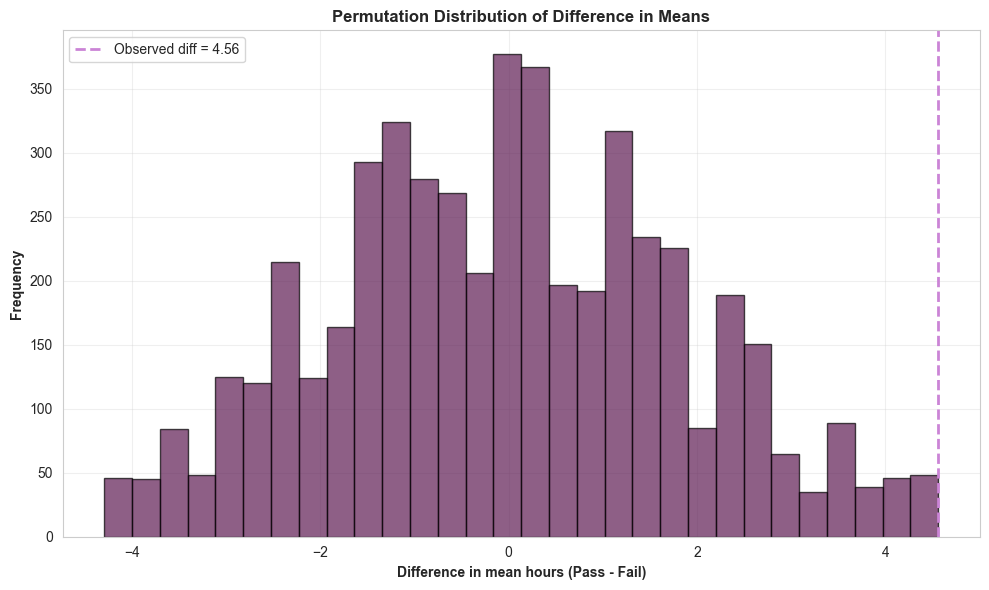

In [109]:
# test if students who passed have higher average hours studied than those who failed
pass_hours = dfstud[dfstud['result'] == 1]['hours_studied']
fail_hours = dfstud[dfstud['result'] == 0]['hours_studied']
obs_diff = pass_hours.mean() - fail_hours.mean()

# permutation test
n_perm = 5000
diffs = []
combined = np.concatenate([pass_hours, fail_hours])
n_pass = len(pass_hours)
for _ in range(n_perm):
    np.random.shuffle(combined)
    new_pass = combined[:n_pass]
    new_fail = combined[n_pass:]
    diffs.append(new_pass.mean() - new_fail.mean())
diffs = np.array(diffs)
p_value = np.mean(np.abs(diffs) >= abs(obs_diff))

print(f"Observed difference in mean hours studied: {obs_diff:.2f}")
print(f"Permutation p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference at α=0.05")
else:
    print("Result: No significant difference")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(diffs, bins=30, color=primary, edgecolor='black', alpha=0.7)
ax.axvline(obs_diff, color=secondary, linestyle='--', linewidth=2, label=f'Observed diff = {obs_diff:.2f}')
ax.set_xlabel('Difference in mean hours (Pass - Fail)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Permutation Distribution of Difference in Means', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2. Kaggle Dataset**

Observed difference in mean age (Survived - Died): -1.86
Permutation p-value: 0.0346
Result: Significant difference at α=0.05


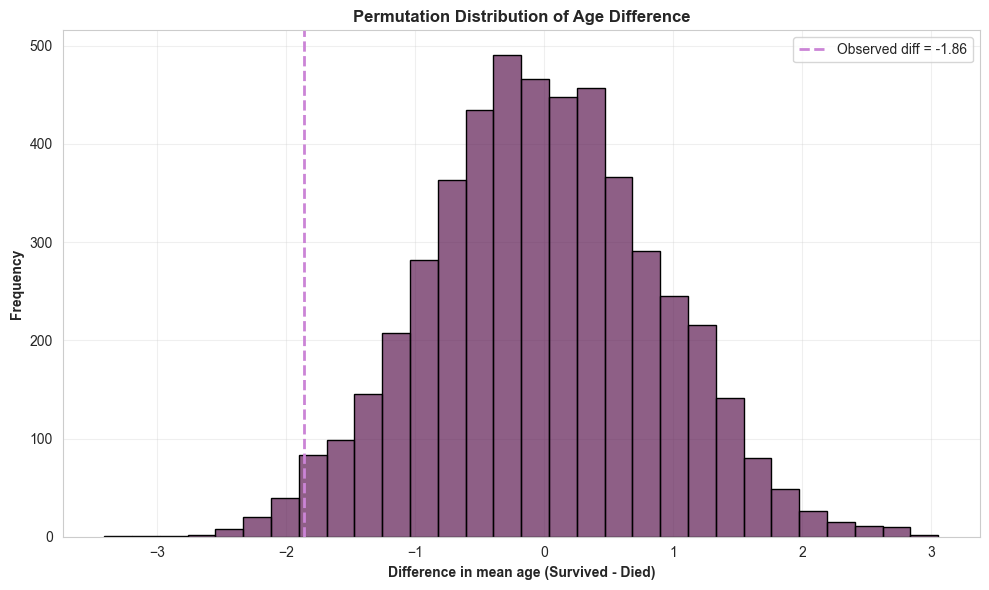

In [110]:
# test if age differs between survivors and non-survivors (using cleaned data)
surv_age = dftit[dftit['Survived'] == 1]['Age']
died_age = dftit[dftit['Survived'] == 0]['Age']
obs_diff = surv_age.mean() - died_age.mean()

# permutation test
n_perm = 5000
diffs = []
combined = np.concatenate([surv_age, died_age])
n_surv = len(surv_age)
for _ in range(n_perm):
    np.random.shuffle(combined)
    new_surv = combined[:n_surv]
    new_died = combined[n_surv:]
    diffs.append(new_surv.mean() - new_died.mean())
diffs = np.array(diffs)
p_value = np.mean(np.abs(diffs) >= abs(obs_diff))

print(f"Observed difference in mean age (Survived - Died): {obs_diff:.2f}")
print(f"Permutation p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference at α=0.05")
else:
    print("Result: No significant difference")

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(diffs, bins=30, color=primary, edgecolor='black', alpha=0.7, ax=ax)
ax.axvline(obs_diff, color=secondary, linestyle='--', linewidth=2, label=f'Observed diff = {obs_diff:.2f}')
ax.set_xlabel('Difference in mean age (Survived - Died)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Permutation Distribution of Age Difference', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**3. Iris Dataset**

In [111]:
# test if sepal length differs between setosa and versicolor
setosa_sepal = dfiris[dfiris['species_id'] == 0]['sepal length (cm)']
versicolor_sepal = dfiris[dfiris['species_id'] == 1]['sepal length (cm)']
obs_diff = setosa_sepal.mean() - versicolor_sepal.mean()

# permutation test
n_perm = 5000
diffs = []
combined = np.concatenate([setosa_sepal, versicolor_sepal])
n_setosa = len(setosa_sepal)
for _ in range(n_perm):
    np.random.shuffle(combined)
    new_setosa = combined[:n_setosa]
    new_versicolor = combined[n_setosa:]
    diffs.append(new_setosa.mean() - new_versicolor.mean())
diffs = np.array(diffs)
p_value = np.mean(np.abs(diffs) >= abs(obs_diff))

print(f"Observed difference in mean sepal length (Setosa - Versicolor): {obs_diff:.2f}")
print(f"Permutation p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference at α=0.05")
else:
    print("Result: No significant difference")

Observed difference in mean sepal length (Setosa - Versicolor): -0.93
Permutation p-value: 0.0000
Result: Significant difference at α=0.05


### Topic 7 - Correlation & Covariance

Correlation measures the strength and direction of a linear relationship between two variables. Covariance is a related measure. Visualising a correlation matrix helps identify which features move together.

**1. User-defined Dataset**

Correlation matrix:
                       hours_studied  attendance  assignments_completed  \
hours_studied               1.000000    0.955910               0.951775   
attendance                  0.955910    1.000000               0.964936   
assignments_completed       0.951775    0.964936               1.000000   
sleep_hours                 0.600432    0.573492               0.615292   
test_score                  0.990366    0.969144               0.974024   

                       sleep_hours  test_score  
hours_studied             0.600432    0.990366  
attendance                0.573492    0.969144  
assignments_completed     0.615292    0.974024  
sleep_hours               1.000000    0.665636  
test_score                0.665636    1.000000  

Covariance matrix:
                       hours_studied  attendance  assignments_completed  \
hours_studied               7.242667   28.280000               5.822222   
attendance                 28.280000  120.844444              24.

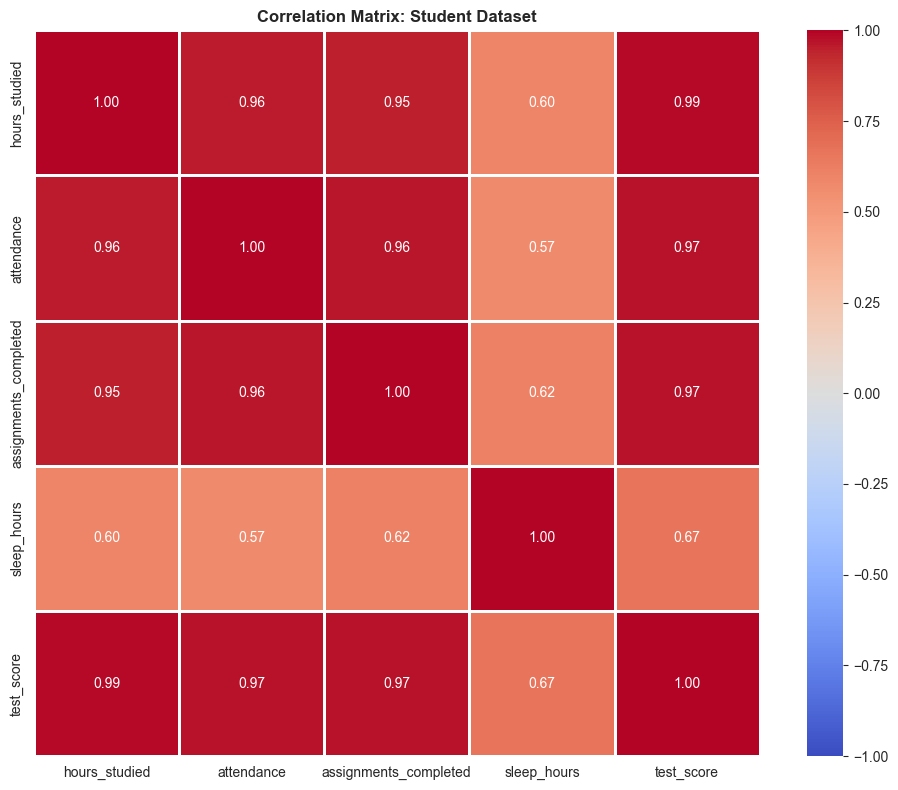

In [112]:
corr_matrix = dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours', 'test_score']].corr()
print("Correlation matrix:")
print(corr_matrix)
print("\nCovariance matrix:")
print(dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours', 'test_score']].cov())

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0, square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix: Student Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

**2. Kaggle Dataset**

Correlation with Survival:
Survived    1.000000
Pclass     -0.335549
Sex         0.541585
Age        -0.069822
SibSp      -0.034040
Parch       0.083151
Fare        0.255290
Name: Survived, dtype: float64


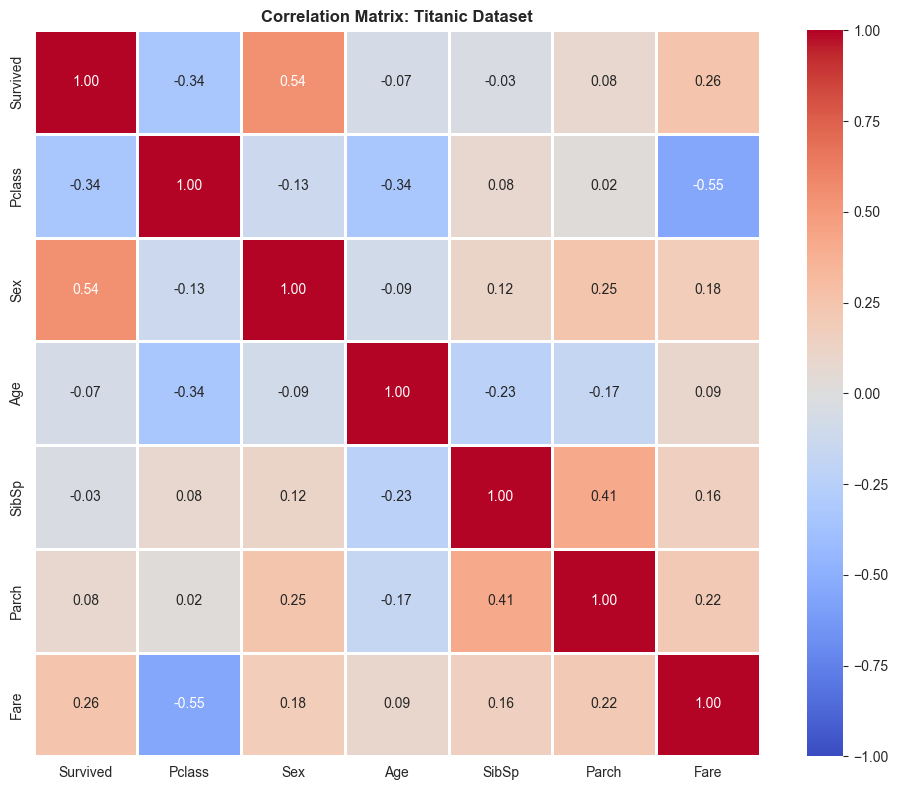

In [113]:
# use cleaned numeric columns
titanic_numeric = dftit[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
corr_matrix = titanic_numeric.corr()
print("Correlation with Survival:")
print(corr_matrix['Survived'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0, square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix: Titanic Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

**3. Iris Dataset**

Correlation matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


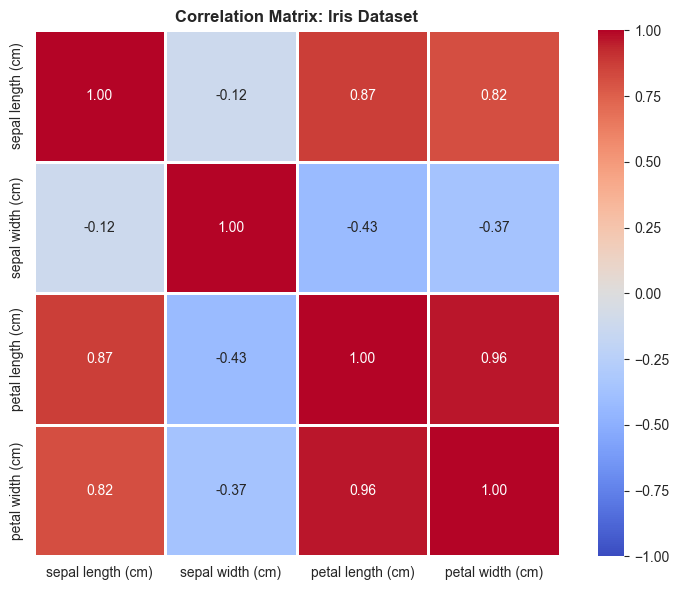

In [114]:
iris_numeric = dfiris[iris.feature_names]
corr_matrix = iris_numeric.corr()
print("Correlation matrix:")
print(corr_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0, square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix: Iris Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

### Topic 8 - Linear Algebra

Linear algebra underpins many machine learning algorithms. Matrix operations such as multiplication, inversion, and solving linear systems are used to compute model parameters.

**1. User-defined Dataset**

In [115]:
# prepare design matrix and target
x = dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours']].values
y = dfstud['test_score'].values

# add intercept column
x1 = np.hstack([np.ones((x.shape[0], 1)), x])

# compute coefficients using normal equation: w = (x^T x)^-1 x^T y
xtx = x1.T @ x1
xtx_inv = np.linalg.inv(xtx)
xty = x1.T @ y
w = xtx_inv @ xty

print("Coefficients from normal equation (includes intercept):")
print(w)

# compare with sklearn's linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours']], dfstud['test_score'])
print("\nSklearn coefficients (intercept + slopes):")
print([lr.intercept_] + list(lr.coef_))
print("Match:", np.allclose(w, [lr.intercept_] + list(lr.coef_)))

Coefficients from normal equation (includes intercept):
[16.71623563  3.78248239  0.1847199   1.60179774  1.55616226]

Sklearn coefficients (intercept + slopes):
[np.float64(16.716235633894108), np.float64(3.7824823944890356), np.float64(0.18471989977021697), np.float64(1.6017977399704348), np.float64(1.5561622592316935)]
Match: True


**2. Kaggle Dataset**

In [116]:
# solve for linear regression weights to predict Fare using cleaned data
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']
x_tit = dftit[features].values
y_tit = dftit['Fare'].values

# add intercept
x_tit = np.hstack([np.ones((x_tit.shape[0], 1)), x_tit])

# compute weights
xtx = x_tit.T @ x_tit
xtx_inv = np.linalg.inv(xtx)
xty = x_tit.T @ y_tit
w = xtx_inv @ xty

print("Coefficients for predicting Fare (intercept + features):")
print(w)

Coefficients for predicting Fare (intercept + features):
[105.63517969 -33.75590058   5.31810202  -0.13850234   5.79088069
   9.54230862]


**3. Iris Dataset**

In [117]:
# use PCA to compute eigenvalues and eigenvectors
x_iris = dfiris[iris.feature_names].values
x_centered = x_iris - x_iris.mean(axis=0)
cov_matrix = (x_centered.T @ x_centered) / (x_centered.shape[0] - 1)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues of covariance matrix:")
print(eigenvalues)
print("\nEigenvectors (columns):")
print(eigenvectors)
print("\nVariance explained by each principal component:")
print(eigenvalues / eigenvalues.sum())

Eigenvalues of covariance matrix:
[4.22824171 0.24267075 0.0782095  0.02383509]

Eigenvectors (columns):
[[ 0.36138659 -0.65658877 -0.58202985  0.31548719]
 [-0.08452251 -0.73016143  0.59791083 -0.3197231 ]
 [ 0.85667061  0.17337266  0.07623608 -0.47983899]
 [ 0.3582892   0.07548102  0.54583143  0.75365743]]

Variance explained by each principal component:
[0.92461872 0.05306648 0.01710261 0.00521218]


### Topic 9 - Calculus Basics

Calculus is used to optimise machine learning models. Gradients tell us how to adjust parameters to reduce the loss function. We can visualise a loss surface and the optimal point using linear regression's closed-form solution.

**1. User-defined Dataset**

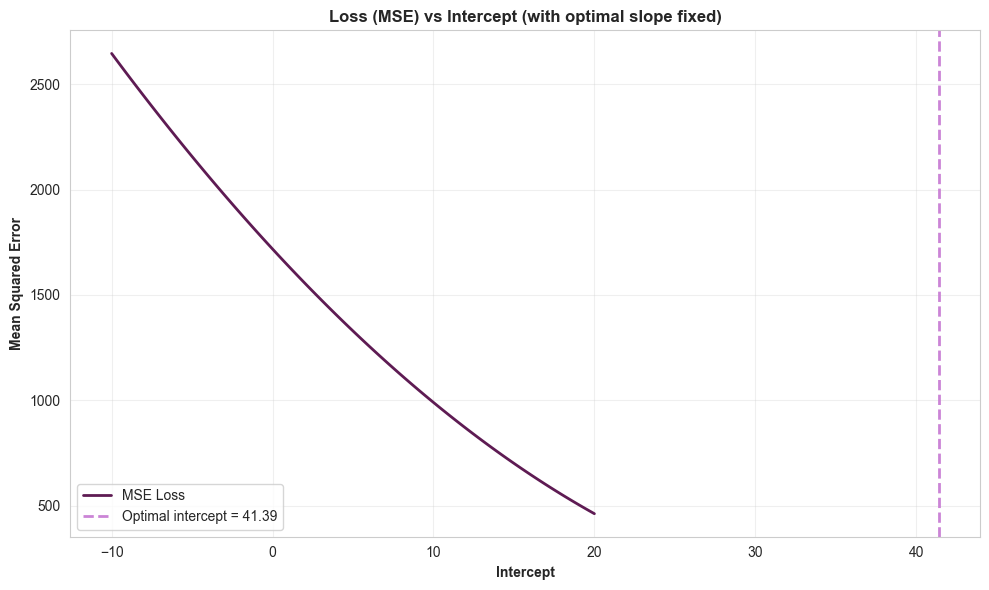

Optimal intercept from LinearRegression: 41.39
Optimal slope: 6.15


In [118]:
# compute MSE for different intercept values using sklearn's mean_squared_error
from sklearn.metrics import mean_squared_error

# use hours_studied as single predictor
X = dfstud[['hours_studied']].values
y = dfstud['test_score'].values

# fit linear regression to get optimal slope and intercept
lr = LinearRegression()
lr.fit(X, y)
optimal_intercept = lr.intercept_
optimal_slope = lr.coef_[0]

# vary intercept, keep slope fixed at optimal
intercepts = np.linspace(-10, 20, 100)
losses = []
for c in intercepts:
    y_pred = c + optimal_slope * X.ravel()
    loss = mean_squared_error(y, y_pred)
    losses.append(loss)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(intercepts, losses, color=primary, linewidth=2, label='MSE Loss')
ax.axvline(optimal_intercept, color=secondary, linestyle='--', linewidth=2, label=f'Optimal intercept = {optimal_intercept:.2f}')
ax.set_xlabel('Intercept', fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontweight='bold')
ax.set_title('Loss (MSE) vs Intercept (with optimal slope fixed)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal intercept from LinearRegression: {optimal_intercept:.2f}")
print(f"Optimal slope: {optimal_slope:.2f}")

**2. Kaggle Dataset**

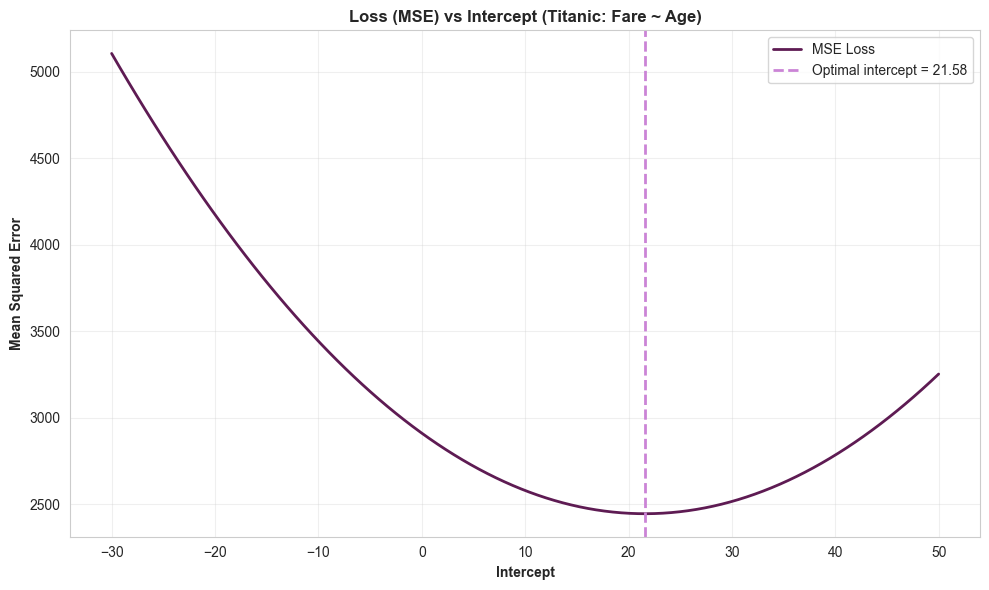

Optimal intercept: 21.58
Optimal slope: 0.36


In [119]:
# use Age to predict Fare (cleaned)
X = dftit[['Age']].values
y = dftit['Fare'].values
lr = LinearRegression()
lr.fit(X, y)
optimal_intercept = lr.intercept_
optimal_slope = lr.coef_[0]

intercepts = np.linspace(-30, 50, 100)
losses = []
for c in intercepts:
    y_pred = c + optimal_slope * X.ravel()
    loss = mean_squared_error(y, y_pred)
    losses.append(loss)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(intercepts, losses, color=primary, linewidth=2, label='MSE Loss')
ax.axvline(optimal_intercept, color=secondary, linestyle='--', linewidth=2, label=f'Optimal intercept = {optimal_intercept:.2f}')
ax.set_xlabel('Intercept', fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontweight='bold')
ax.set_title('Loss (MSE) vs Intercept (Titanic: Fare ~ Age)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal intercept: {optimal_intercept:.2f}")
print(f"Optimal slope: {optimal_slope:.2f}")

**3. Iris Dataset**

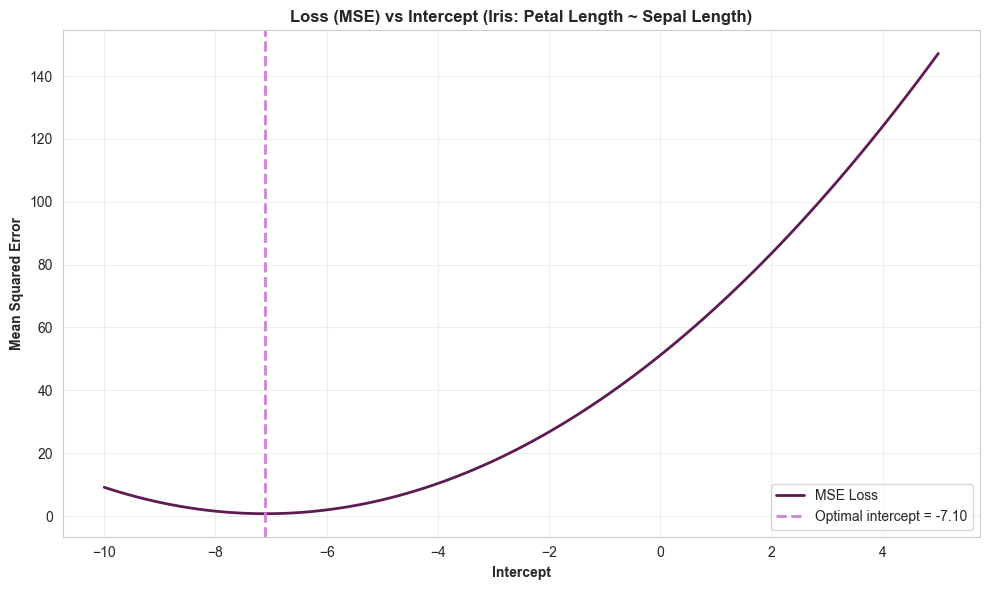

Optimal intercept: -7.10
Optimal slope: 1.86


In [120]:
# use sepal length to predict petal length
X = dfiris[['sepal length (cm)']].values
y = dfiris['petal length (cm)'].values
lr = LinearRegression()
lr.fit(X, y)
optimal_intercept = lr.intercept_
optimal_slope = lr.coef_[0]

intercepts = np.linspace(-10, 5, 100)
losses = []
for c in intercepts:
    y_pred = c + optimal_slope * X.ravel()
    loss = mean_squared_error(y, y_pred)
    losses.append(loss)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(intercepts, losses, color=primary, linewidth=2, label='MSE Loss')
ax.axvline(optimal_intercept, color=secondary, linestyle='--', linewidth=2, label=f'Optimal intercept = {optimal_intercept:.2f}')
ax.set_xlabel('Intercept', fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontweight='bold')
ax.set_title('Loss (MSE) vs Intercept (Iris: Petal Length ~ Sepal Length)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal intercept: {optimal_intercept:.2f}")
print(f"Optimal slope: {optimal_slope:.2f}")

### Topic 10 - Regression

Regression predicts a continuous target variable. Linear regression finds a linear relationship between features and the target. We evaluate performance using metrics like MAE and RMSE.

**1. User-defined Dataset**

Intercept: 22.3995
Coefficients:
  hours_studied: 4.2458
  attendance: 0.1490
  assignments_completed: 1.0005
  sleep_hours: 1.4535

MAE: 1.3831
RMSE: 1.5591


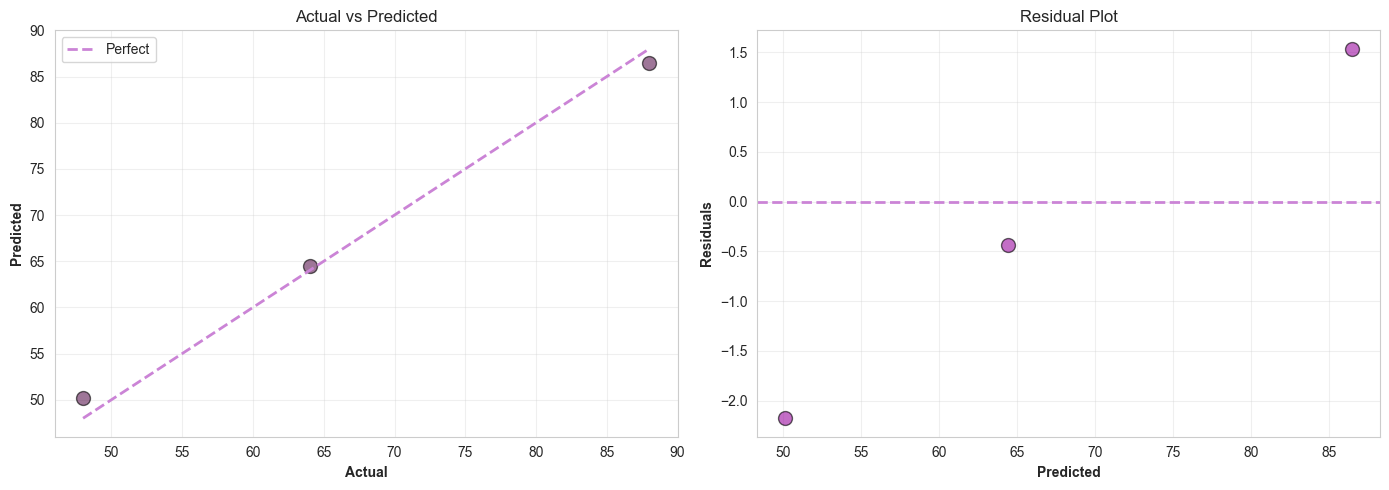

In [121]:
x = dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours']]
y = dfstud['test_score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

print(f"Intercept: {lr.intercept_:.4f}")
print("Coefficients:")
for feat, coef in zip(x.columns, lr.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"\nMAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred, alpha=0.6, color=primary, edgecolors='black', s=100)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color=secondary, linestyle='--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual', fontweight='bold')
axes[0].set_ylabel('Predicted', fontweight='bold')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color=accent, edgecolors='black', s=100)
axes[1].axhline(0, color=secondary, linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('Residuals', fontweight='bold')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2. Kaggle Dataset**

MAE: 20.7503
RMSE: 42.5716


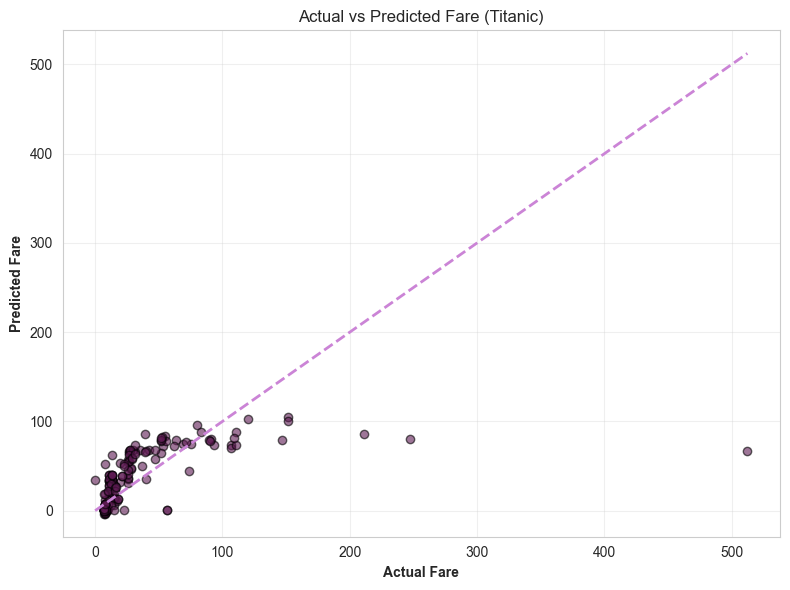

In [122]:
# predict Fare using passenger class, sex, age, etc.
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']
x = dftit[features]
y = dftit['Fare']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.6, color=primary, edgecolors='black')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color=secondary, linestyle='--', linewidth=2)
ax.set_xlabel('Actual Fare', fontweight='bold')
ax.set_ylabel('Predicted Fare', fontweight='bold')
ax.set_title('Actual vs Predicted Fare (Titanic)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**3. Iris Dataset**

MAE: 0.4863
RMSE: 0.5937


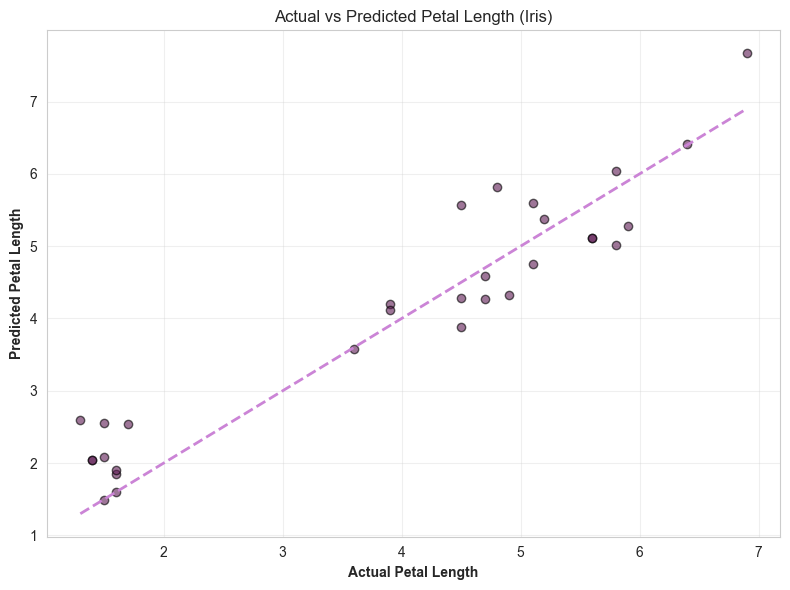

In [123]:
# predict petal length from sepal length and width
x = dfiris[['sepal length (cm)', 'sepal width (cm)']]
y = dfiris['petal length (cm)']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.6, color=primary, edgecolors='black')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color=secondary, linestyle='--', linewidth=2)
ax.set_xlabel('Actual Petal Length', fontweight='bold')
ax.set_ylabel('Predicted Petal Length', fontweight='bold')
ax.set_title('Actual vs Predicted Petal Length (Iris)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Topic 11 - Classification

Classification predicts a categorical class label. Decision trees are intuitive models that split data based on feature values. We evaluate using accuracy, precision, recall, and confusion matrix.

**1. User-defined Dataset**

In [124]:
# predict pass/fail using logistic regression
x = dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours']]
y = dfstud['result']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
y_pred = logreg.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.50      0.67         2
        Pass       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3

Confusion Matrix:
[[1 1]
 [0 1]]


**2. Kaggle Dataset**

Classification Report:
              precision    recall  f1-score   support

    Perished       0.86      0.84      0.85       109
    Survived       0.76      0.78      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178



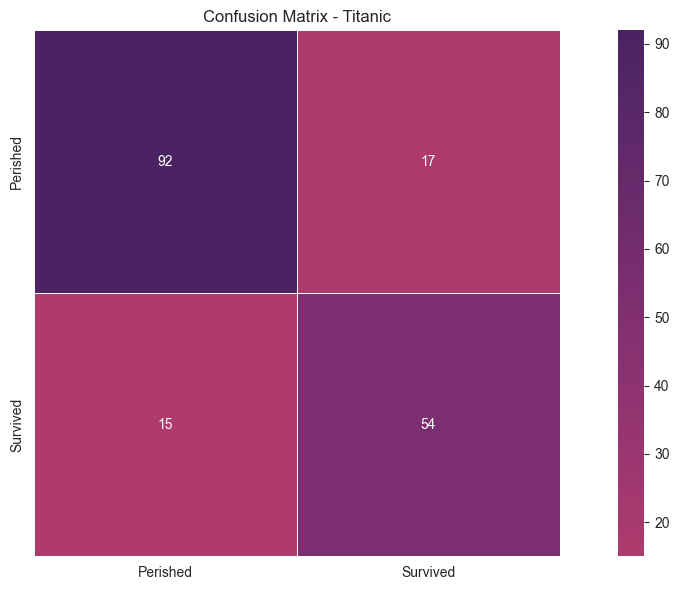

In [141]:
# use decision tree on cleaned data
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
x = dftit[features]
y = dftit['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(x_train, y_train)
y_pred = tree.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Perished', 'Survived']))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='flare', center=0, square=True, linewidths=0.5, xticklabels=['Perished', 'Survived'], yticklabels=['Perished', 'Survived'])
plt.title('Confusion Matrix - Titanic')
plt.tight_layout()
plt.show()

**3. Iris Dataset**

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



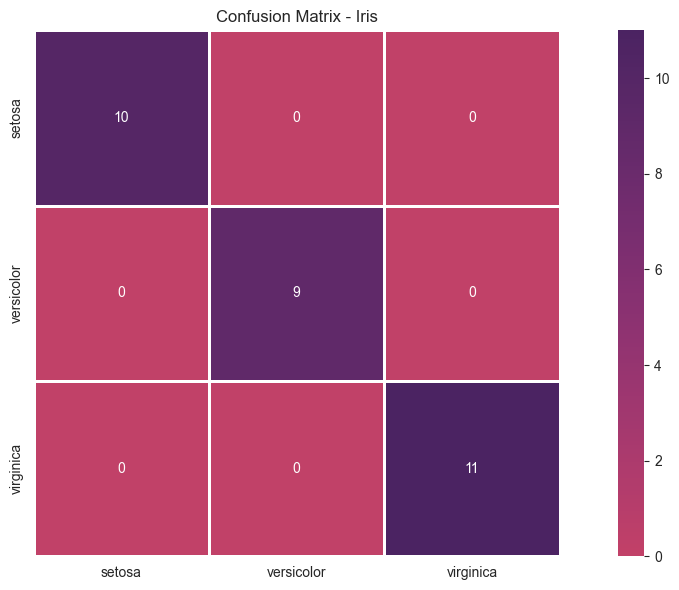

In [150]:
# classify species using decision tree
x = dfiris[iris.feature_names]
y = dfiris['species_id']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(x_train, y_train)
y_pred = tree.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', center=0, square=True, cmap='flare', linewidths=1, xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - Iris')
plt.tight_layout()
plt.show()

### Topic 12 - Clustering

Clustering groups similar data points together without using labels. K-Means is a popular algorithm. We use the elbow method to choose the number of clusters and visualise the results.

**1. User-defined Dataset**

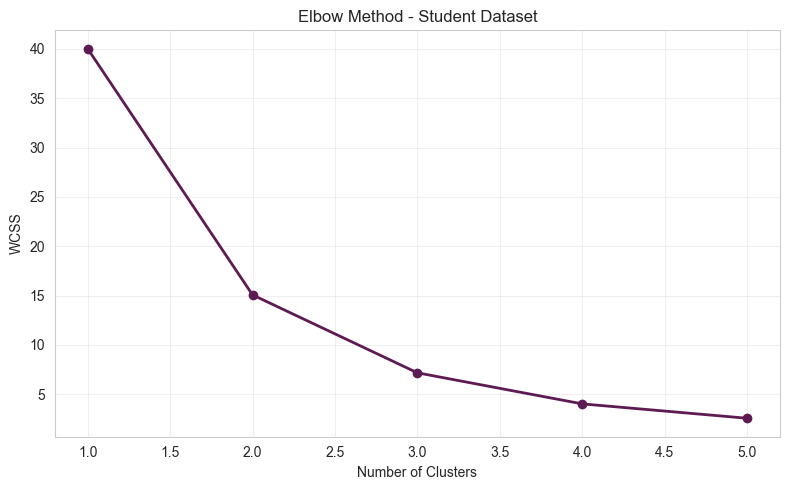

Cluster sizes:
cluster
1    6
0    4
Name: count, dtype: int64


In [127]:
# cluster students based on study habits
x = dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# elbow method
wcss = []
for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 6), wcss, marker='o', color=primary, linewidth=2)
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('WCSS')
ax.set_title('Elbow Method - Student Dataset')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# choose k=2 for demonstration
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
dfstud['cluster'] = kmeans.fit_predict(x_scaled)
print("Cluster sizes:")
print(dfstud['cluster'].value_counts())

**2. Kaggle Dataset**

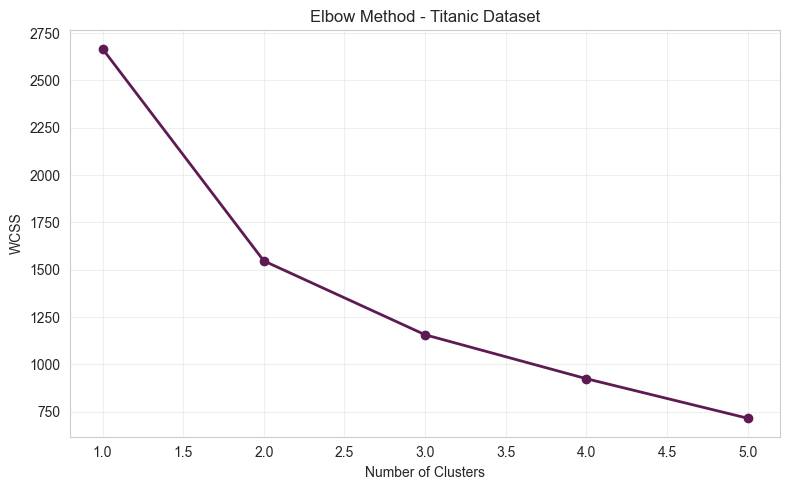

Cluster sizes:
cluster
0    600
1    247
2     42
Name: count, dtype: int64


In [128]:
# cluster passengers based on age, fare, class
x = dftit[['Pclass', 'Age', 'Fare']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

wcss = []
for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 6), wcss, marker='o', color=primary, linewidth=2)
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('WCSS')
ax.set_title('Elbow Method - Titanic Dataset')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dftit['cluster'] = kmeans.fit_predict(x_scaled)
print("Cluster sizes:")
print(dftit['cluster'].value_counts())

**3. Iris Dataset**

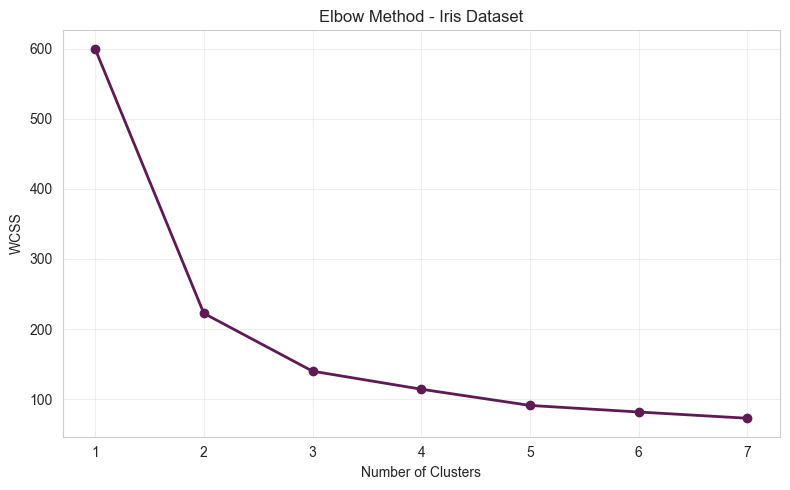

Cluster assignment vs species:
cluster        0   1   2
species_name            
setosa         0  50   0
versicolor    39   0  11
virginica     14   0  36


In [129]:
x = dfiris[iris.feature_names]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# elbow method
wcss = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 8), wcss, marker='o', color=primary, linewidth=2)
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('WCSS')
ax.set_title('Elbow Method - Iris Dataset')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dfiris['cluster'] = kmeans.fit_predict(x_scaled)
print("Cluster assignment vs species:")
print(pd.crosstab(dfiris['species_name'], dfiris['cluster']))

### Topic 13 - Principal Component Analysis (PCA)

PCA reduces dimensionality by projecting data onto principal components that capture the most variance. This helps visualise high-dimensional data and can improve model performance.

**1. User-defined Dataset**

Explained variance ratio: [0.8415283  0.13764515]
Total variance explained: 97.92%


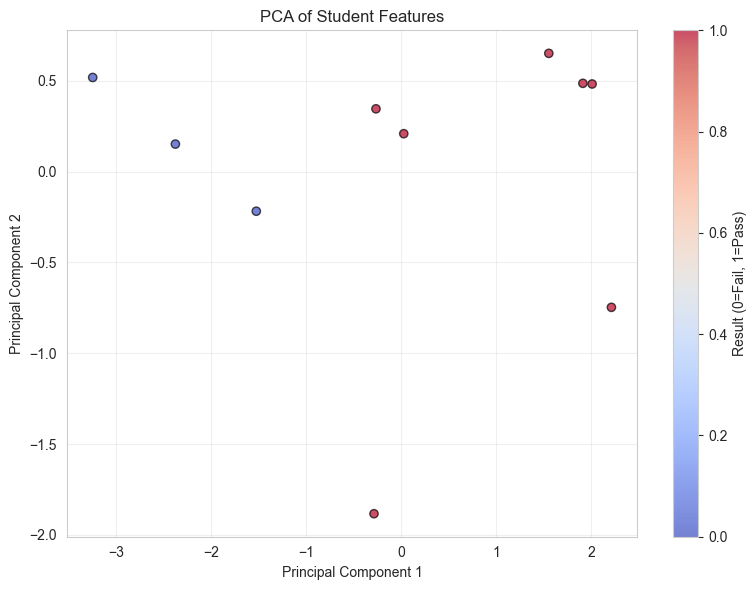

In [130]:
x = dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(x_pca[:, 0], x_pca[:, 1], c=dfstud['result'], cmap='coolwarm', alpha=0.7, edgecolors='black')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA of Student Features')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Result (0=Fail, 1=Pass)')
plt.tight_layout()
plt.show()

**2. Kaggle Dataset**

Explained variance ratio: [0.29946009 0.27968984]
Total: 57.91%


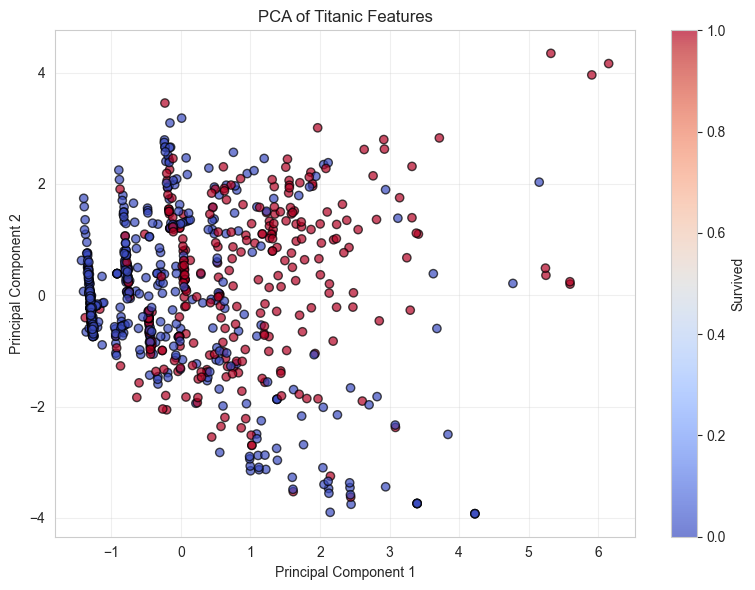

In [131]:
x = dftit[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(x_pca[:, 0], x_pca[:, 1], c=dftit['Survived'], cmap='coolwarm', alpha=0.7, edgecolors='black')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA of Titanic Features')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Survived')
plt.tight_layout()
plt.show()

**3. Iris Dataset**

Explained variance ratio: [0.72962445 0.22850762]
Total: 95.81%


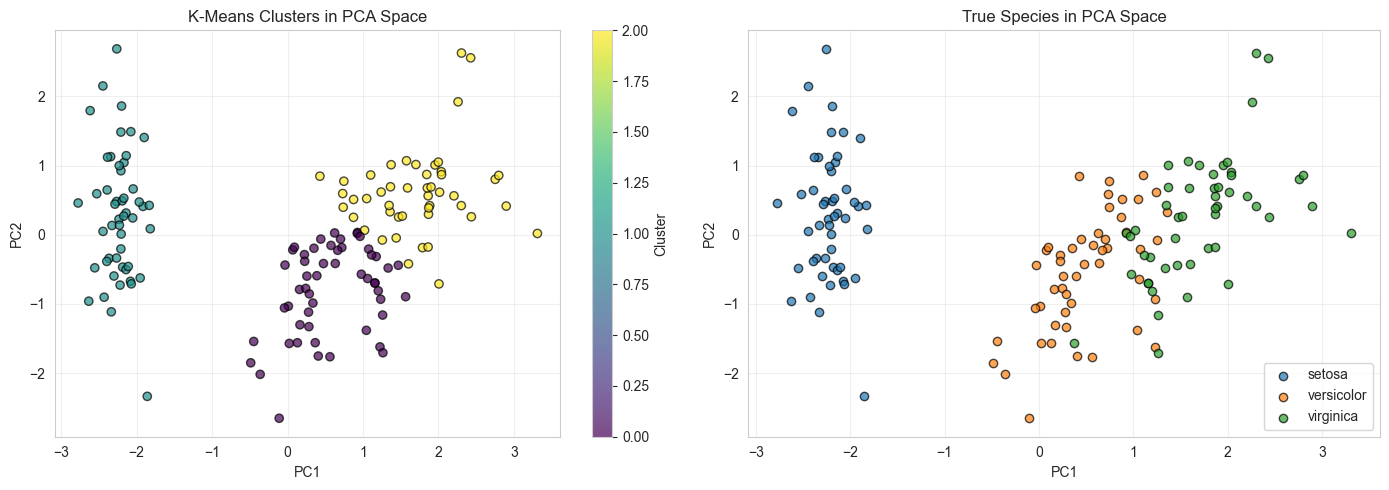

In [132]:
x = dfiris[iris.feature_names]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter1 = axes[0].scatter(x_pca[:, 0], x_pca[:, 1], c=dfiris['cluster'], cmap='viridis', alpha=0.7, edgecolors='black')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('K-Means Clusters in PCA Space')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')
axes[0].grid(True, alpha=0.3)

for species in dfiris['species_name'].unique():
    mask = dfiris['species_name'] == species
    axes[1].scatter(x_pca[mask, 0], x_pca[mask, 1], label=species, alpha=0.7, edgecolors='black')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('True Species in PCA Space')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Topic 14 - Model Evaluation

Evaluation metrics help us assess model performance. For regression we use MAE, RMSE, R²; for classification we use accuracy, precision, recall, F1, and cross-validation scores.

**1. User-defined Dataset**

In [133]:
# evaluate regression model
x = dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours']]
y = dfstud['test_score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

print("Regression Metrics:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²: {lr.score(x_test, y_test):.4f}")

# cross-validation
cv_scores = cross_val_score(lr, x, y, cv=5, scoring='r2')
print(f"Cross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

Regression Metrics:
MAE: 1.3831
RMSE: 1.5591
R²: 0.9910
Cross-validation R² scores: [0.91393356 0.98527547 0.92751295 0.98245999 0.99973593]
Mean CV R²: 0.9618


**2. Kaggle Dataset**

In [134]:
# evaluate classification model
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
x = dftit[features]
y = dftit['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(x_train, y_train)
y_pred = tree.predict(x_test)

print("Classification Metrics:")
print(f"Accuracy: {tree.score(x_test, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Perished', 'Survived']))

# cross-validation
cv_scores = cross_val_score(tree, x, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")

Classification Metrics:
Accuracy: 0.8202

Classification Report:
              precision    recall  f1-score   support

    Perished       0.86      0.84      0.85       109
    Survived       0.76      0.78      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178

Cross-validation accuracy scores: [0.81460674 0.81460674 0.81460674 0.78651685 0.81920904]
Mean CV accuracy: 0.8099


**3. Iris Dataset**

In [135]:
# evaluate classification on Iris
x = dfiris[iris.feature_names]
y = dfiris['species_id']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(x_train, y_train)
y_pred = tree.predict(x_test)

print("Accuracy: {:.4f}".format(tree.score(x_test, y_test)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

cv_scores = cross_val_score(tree, x, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Cross-validation accuracy scores: [0.96666667 0.96666667 0.93333333 1.         1.        ]
Mean CV accuracy: 0.9733


### Topic 15 - Hyperparameter Tuning

Hyperparameters control model complexity. Grid search systematically tries combinations to find the best set, using cross-validation to avoid overfitting.

**1. User-defined Dataset**

In [136]:
# tune decision tree for classification
x = dfstud[['hours_studied', 'attendance', 'assignments_completed', 'sleep_hours']]
y = dfstud['result']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
param_grid = {'max_depth': [2, 3, 4, 5], 'min_samples_split': [2, 3, 4]}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid.fit(x_train, y_train)
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")
print(f"Test accuracy with best model: {grid.score(x_test, y_test):.4f}")

Best parameters: {'max_depth': 2, 'min_samples_split': 2}
Best CV accuracy: 0.8889
Test accuracy with best model: 0.6667


**2. Kaggle Dataset**

In [137]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
x = dftit[features]
y = dftit['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
param_grid = {'max_depth': [2, 3, 4, 5, 6], 'min_samples_split': [2, 3, 4]}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(x_train, y_train)
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")
print(f"Test accuracy with best model: {grid.score(x_test, y_test):.4f}")

Best parameters: {'max_depth': 3, 'min_samples_split': 2}
Best CV accuracy: 0.8200
Test accuracy with best model: 0.8202


**3. Iris Dataset**

In [138]:
x = dfiris[iris.feature_names]
y = dfiris['species_id']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
param_grid = {'max_depth': [2, 3, 4, 5], 'min_samples_split': [2, 3, 4]}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(x_train, y_train)
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")
print(f"Test accuracy with best model: {grid.score(x_test, y_test):.4f}")

Best parameters: {'max_depth': 4, 'min_samples_split': 2}
Best CV accuracy: 0.9417
Test accuracy with best model: 1.0000


### Summary

This notebook covered all 15 core machine learning topics in a logical order:

**Exploratory & Foundational [Topics 1-3]**:
1. Descriptive Statistics: summarised data using mean, median, standard deviation
2. Probability: examined conditional probabilities and Bayes' theorem
3. Probability Distributions: visualised distributions and fitted normal curves

**Data Preparation [Topic 4]**:
4. Data Preprocessing: handled missing values, encoded categories, scaled features

**Inferential & Mathematical [Topics 5-9]**:

5. Sampling & CLT: used bootstrap to estimate confidence intervals
6. Hypothesis Testing: performed permutation tests to compare group means
7. Correlation & Covariance: analysed feature relationships with heatmaps
8. Linear Algebra: used matrix operations to compute model weights and eigenvectors
9. Calculus Basics: visualised loss surfaces using MSE and linear regression

**Modelling & Optimisation [Topics 10-15]**:

10. Regression: predicted continuous outcomes with linear models
11. Classification: predicted categorical outcomes with decision trees
12. Clustering: discovered groups using K-Means and the elbow method
13. PCA: reduced dimensionality while preserving variance
14. Model Evaluation: assessed performance using multiple metrics and cross-validation
15. Hyperparameter Tuning: optimised models using grid search

Across three datasets, I demonstrated how these concepts work in practice, with the Titanic dataset cleaned upfront to ensure consistency.